 Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import os
import zipfile
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

 Download Flickr8k Dataset

 Flickr8k dataset - It contains images along with human-written descriptions (captions).

 8000 images showing real-world photograps of people, Animals, Sports, nature, Daily activities
 Caption per image is 5

8000 images and 40,000 text descriptions

Dataset Split up - Training (6000), Testing (1000), validation set (1000)

In [ ]:
!wget "https://github.com/awsaf49/flickr-dataset/releases/download/v1.0/flickr8k.zip"
!unzip -q flickr8k.zip -d ./flickr8k

--2026-04-30 14:32:04--  https://github.com/awsaf49/flickr-dataset/releases/download/v1.0/flickr8k.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/753516996/d7c62b13-1e50-40ea-8fae-f34a44b1695f?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-30T15%3A28%3A46Z&rscd=attachment%3B+filename%3Dflickr8k.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-30T14%3A28%3A01Z&ske=2026-04-30T15%3A28%3A46Z&sks=b&skv=2018-11-09&sig=oVy1k8LKVcO5YKg7rz1wo0NXciA5VNtaw4QE2ZsiPOg%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NzU2MzEyNCwibmJmIjoxNzc3NTU5NTI0LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmN

In [ ]:
print(os.listdir("flickr8k"))

['Images', 'captions.txt']


Checking Number of Images

In [ ]:
print(len(os.listdir("flickr8k/Images")))

8091


Show first 20 files

In [ ]:
files = os.listdir("flickr8k/Images")
print(files[:20])

['3323528927_7b21081271.jpg', '2417745327_a2c2705043.jpg', '818340833_7b963c0ee3.jpg', '3718076407_0b4588d7bc.jpg', '265223843_9ef21e1872.jpg', '3183195653_11b66acb34.jpg', '3330680118_4e541889c1.jpg', '3429391520_930b153f94.jpg', '1030985833_b0902ea560.jpg', '2738255684_0324ed062d.jpg', '3207343907_995f7ac1d2.jpg', '3165826902_6bf9c4bdb2.jpg', '464506846_1734302b58.jpg', '2414384480_096867d695.jpg', '2863027424_9c75105660.jpg', '534200447_b0f3ff02be.jpg', '961189263_0990f3bcb5.jpg', '3474958471_9106beb07f.jpg', '3635911776_dbc2763f2c.jpg', '3209523192_05a4cef844.jpg']


Checks Caption Count

In [ ]:
with open("flickr8k/captions.txt","r") as f:
    lines = f.readlines()
print(len(lines))

40456


Loading Pretrained CNN Encoder

In [ ]:
model = InceptionV3(weights='imagenet')
model = tf.keras.Model(
    model.input,
    model.layers[-2].output
)

model_encoder = model
print("Encoder Loaded")

Encoder Loaded


Extract Image Features

In [ ]:
def extract_features(directory):

    features={}

    for img in os.listdir(directory)[:100]:
        path=directory+"/"+img

        image=load_img(path,target_size=(299,299))
        image=img_to_array(image)

        image=np.expand_dims(image,axis=0)
        image=preprocess_input(image)

        feature=model.predict(image,verbose=0)

        features[img]=feature

    return features

features = extract_features("flickr8k/Images")
print("Feature extraction completed")

Feature extraction completed


Load Captions

In [ ]:
def load_captions(filename):

    mapping={}

    with open(filename,'r') as file:

        for line in file:
            tokens=line.strip().split(',')

            img_id=tokens[0]
            caption=" ".join(tokens[1:])

            if img_id not in mapping:
                mapping[img_id]=[]

            mapping[img_id].append(
                "startseq " + caption + " endseq"
            )

    return mapping

captions=load_captions(
    "flickr8k/captions.txt"
)

print("Captions Loaded")

Captions Loaded


Create Tokenizer (Convert Words to Numbers)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

all_captions=[]

for key in captions:
    for cap in captions[key]:
        all_captions.append(cap)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index)+1

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 8497


Find Maximum Caption Length

In [ ]:
max_length = max(
    len(c.split())
    for c in all_captions
)

print("Max Caption Length:", max_length)

Max Caption Length: 39


Create Training Sequences

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Training data lists
X1 = []
X2 = []
y = []

count = 0

for img, caption_list in captions.items():

    # Skip if image feature not extracted
    if img not in features:
        continue

    for caption in caption_list:

        # Convert caption words to numbers
        seq = tokenizer.texts_to_sequences(
            [caption]
        )[0]

        # Create input-output pairs
        for i in range(1, len(seq)):

            # Input sequence
            in_seq = seq[:i]

            # Next word (target)
            out_seq = seq[i]

            # Pad sequence
            in_seq = pad_sequences(
                [in_seq],
                maxlen=max_length
            )[0]

            # Store training data
            X1.append(features[img][0])
            X2.append(in_seq)

            # Store target as integer
            y.append(out_seq)

    count += 1

    # Use 50 images first to reduce RAM
    if count == 500:
        break


# Convert lists to arrays
X1 = np.array(X1)
X2 = np.array(X2)
y  = np.array(y)

print("Training data ready")
print(X1.shape)
print(X2.shape)
print(y.shape)

Training data ready
(5880, 2048)
(5880, 39)
(5880,)


Build LSTM Decoder Model

In [ ]:
from tensorflow.keras.layers import Input,Dense,LSTM,Embedding,Dropout,add
from tensorflow.keras.models import Model

inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256,activation='relu')(fe1)

inputs2 = Input(shape=(max_length,))

# FIXED
se1 = Embedding(vocab_size,256)(inputs2)

se2 = Dropout(0.5)(se1)
se3 = LSTM(256)(se2)

decoder1 = add([fe2,se3])
decoder2 = Dense(256,activation='relu')(decoder1)

outputs = Dense(
    vocab_size,
    activation='softmax'
)(decoder2)

model = Model(
    inputs=[inputs1,inputs2],
    outputs=outputs
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam'
)

print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 39, 256)   │  2,175,232 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 39, 256)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    524,544 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 256)       │    525,312 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ dense_3[0][0],    │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8497)      │  2,183,729 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,474,609 (20.88 MB)

 Trainable params: 5,474,609 (20.88 MB)

 Non-trainable params: 0 (0.00 B)

None


Model Training

In [ ]:
model.fit(
    [X1, X2],
    y,
    epochs=25,
    batch_size=32
)

Epoch 1/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5.7174
Epoch 2/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.5860
Epoch 3/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.9663
Epoch 4/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.4312
Epoch 5/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.9456
Epoch 6/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.5206
Epoch 7/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.2107
Epoch 8/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.9438
Epoch 9/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.7205
Epoch 10/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.5417
Epoch 11/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.3918
Epoch 12/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.2539
Epoch 13/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.1316
Epoch 14/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.0019
Epoch 15/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 1

Generate Caption

In [ ]:
def generate_caption(model, image_feature):

    caption = "startseq"

    for i in range(max_length):

        seq = tokenizer.texts_to_sequences(
            [caption]
        )[0]

        seq = pad_sequences(
            [seq],
            maxlen=max_length
        )

        yhat = model.predict(
            [image_feature, seq],
            verbose=0
        )

        yhat = np.argmax(yhat)

        word = None

        for w, index in tokenizer.word_index.items():
            if index == yhat:
                word = w
                break

        if word is None:
            break

        caption += " " + word

        if word == "endseq":
            break


    # Remove startseq and endseq
    return caption.replace(
        "startseq",""
    ).replace(
        "endseq",""
    ).strip()

Test the Model

In [ ]:
test_img = list(features.keys())[80]

print(test_img)

print(
generate_caption(
    model,
    features[test_img]
)
)

2391812384_7429b5e567.jpg
a child wearing purple runs through splashing water while a man in red looks on


Displaying Image and Caption Together

Generated Caption: a child wearing purple runs through splashing water while a man in red looks on


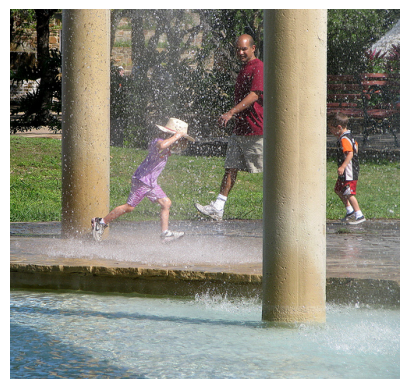

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

test_img = list(features.keys())[80]

img = Image.open(
    "flickr8k/Images/" + test_img
)

plt.imshow(img)
plt.axis("off")

caption = generate_caption(
    model,
    features[test_img]
)

print("Generated Caption:", caption)

In [ ]:
from google.colab import files
files.upload()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
def extract_feature_single(img_path):

    image = load_img(img_path, target_size=(299,299))
    image = img_to_array(image)

    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)

    feature = model_encoder.predict(image, verbose=0)

    return feature

Enter image name: doggy.jpg
Generated Caption: a black dog is running across a large covered and playing


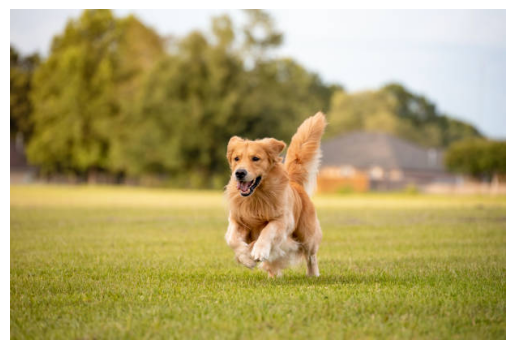

In [67]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = input("Enter image name: ")

img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")

feature = extract_feature_single(img_path)
caption = generate_caption(model, feature)

print("Generated Caption:", caption)